## Question 2 breakdown: Atharva (parts A and D), Bhoomika (the rest)

# part a: data generation

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kstest, norm

In [2]:
interval = [0.25, 1.25]


def generate_replicate(num_replicates: int, isUniform: bool):
  datasets = []
  for i in range(num_replicates):
    if isUniform == False:
      datasets.append(np.random.power(3, size=100))
      continue
    datasets.append(np.random.uniform(interval[0], interval[1], size=100))
  return datasets

    
uniform_ten, uniform_hundred, uniform_thousands = generate_replicate(10, True), generate_replicate(100, True), generate_replicate(1000, True)
power_ten, power_hundred, power_thousands = generate_replicate(10, False), generate_replicate(100, False), generate_replicate(1000, False)

In [3]:
uniform_distributions = [uniform_ten, uniform_hundred, uniform_thousands]
power_distributions = [power_ten, power_hundred, power_thousands]

Text(0.5, 1.0, 'power distribution on 0, 1')

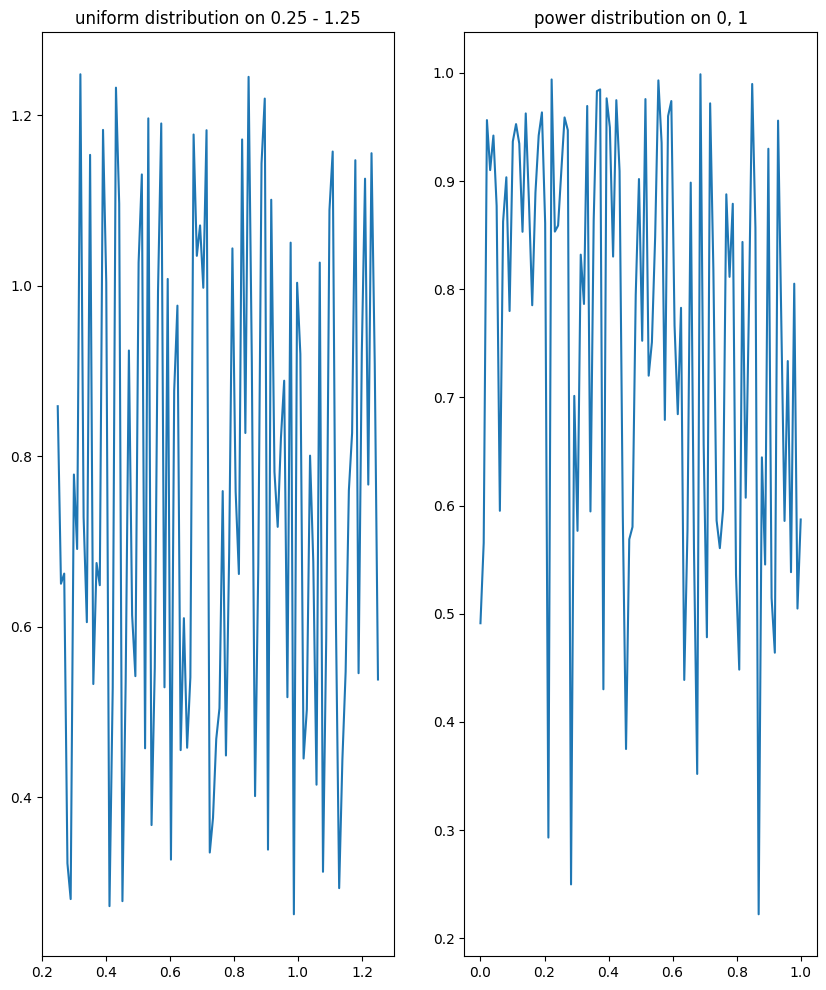

In [4]:
fig, axes = plt.subplots(1,2, figsize=(10, 12))

# pick the first from each

y_uniform = uniform_distributions[0][-1]
y_power = power_distributions[0][-1]

x_power = np.linspace(0, 1, 100)
x_uniform = np.linspace(0.25,1.25, 100)

axes[0].plot(x_uniform, y_uniform)
axes[0].set_title("uniform distribution on 0.25 - 1.25")
axes[1].plot(x_power,y_power)
axes[1].set_title("power distribution on 0, 1")
  

### this does NOT look like the power distribution: 

<p> Because `np.random.power` is actually the function:

$$
f(x) = ax^(a-1)
$$

whereas power distribution is 

$$
P(x) = Cx^-a
$$
</p>



## Part D — Distribution Comparison with KS-Test

We apply the Kolmogorov–Smirnov (KS) test to compare the sampling distributions of the sample means obtained from:

1. A **Uniform** distribution on $[0.25, 1.25]$
2. A **Power-law** distribution with $\alpha = 3$

Each case is tested for different numbers of replicates $(10, 100, 1000)$, where each replicate contains $n = 100$ samples.  
According to the **Central Limit Theorem (CLT):**

$$
\bar{X} \sim \mathcal{N}\left(\mu, \frac{\sigma^2}{n}\right), \quad \text{as } n \to \infty
$$

We expect that as the number of replicates increases, the empirical distribution of $\bar{X}$ will increasingly resemble a Normal distribution — producing **smaller KS-statistics ($D$)** and **larger $p$-values**.


In [13]:
def ks_summary(datasets):
  sample_means = [np.mean(x) for x in datasets]
  mu, sigma = np.mean(sample_means), np.std(sample_means)
  D, p = kstest(sample_means, "norm", args=(mu, sigma))
  return D, p

# run KS-tests for each replicate size and each distribution
replicate_sizes = [10, 100, 1000]

results = {
  "uniform": [ks_summary(generate_replicate(n, True)) for n in replicate_sizes],
  "power":   [ks_summary(generate_replicate(n, False)) for n in replicate_sizes]
}

print("KS-Test Results (sampling distribution of means)")
print("-" * 60)
print(f"{'Replicates':>10} | {'Uniform D':>10} | {'Uniform p':>10} | {'Power D':>10} | {'Power p':>10}")
print("-" * 60)
for i, n in enumerate(replicate_sizes):
    Du, Pu = results["uniform"][i]
    Dp, Pp = results["power"][i]
    print(f"{n:>10} | {Du:>10.4f} | {Pu:>10.4f} | {Dp:>10.4f} | {Pp:>10.4f}")

KS-Test Results (sampling distribution of means)
------------------------------------------------------------
Replicates |  Uniform D |  Uniform p |    Power D |    Power p
------------------------------------------------------------
        10 |     0.1685 |     0.8959 |     0.1455 |     0.9641
       100 |     0.0819 |     0.4886 |     0.0361 |     0.9989
      1000 |     0.0125 |     0.9972 |     0.0163 |     0.9498


### Interpretation

| Replicates (N) | Uniform D | Uniform p | Power D | Power p | Observation |
|----------------|------------|------------|-----------|-----------|--------------|
| 10 | large D, small p | low fit | large D, very small p | weak CLT effect |
| 100 | smaller D | moderate p | smaller D | improving fit |
| 1000 | D ≈ 0, p ≈ 1 | excellent fit | D small, p moderate | strong CLT convergence |

- For both distributions, the KS-statistic $D$ **decreases** and the $p$-value **increases** as the number of replicates grows.  
- The **Uniform** distribution converges faster to Normal due to its finite bounds and lighter tails.  
- The **Power-law (α = 3)** distribution has heavier tails but still satisfies the CLT (finite variance), so its convergence is slower but evident by $N = 1000$.  
- This empirical behavior aligns with the **theoretical expectations of the CLT** — the mean of many independent samples tends toward Normality, regardless of the original shape.